<a href="https://colab.research.google.com/github/ichika-yay/Economics-Brawl-Stars/blob/main/%E9%A3%BD%E5%92%8C%E7%84%A1%E7%95%B0%E6%9B%B2%E7%B7%9A%E7%90%86%E8%AB%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**同為藥物與調劑的狂熱者，藥師拜倫很愛去逛保力的酒牆。琳瑯滿目的瘋狂飲料，讓拜倫擁有無數種消費組合和結構。**

**模型B:飽和點模型（超過飽和點MU可能為負）**<br>拜倫是個不怕死，追求刺激的瘋子藥師。保力於是推薦了煉辣酒和亂醉湯給拜倫。這兩款飲品味道強勁有個性，能帶來酥麻且清爽的快感，就是喝多了傷腸胃。

**1.計算最適消費組合:** 使用者輸入經濟參數後，使用效用函數: -(X-S1)^2-(X-S2)^2
計算最大效用值，如果最適組合為內生解，用MRS=Px/Py進行數理驗證

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
print("=====保力酒吧開張(模型B)=====")
print("請輸入今晚的酒吧經濟參數:")
def cor_input(prompt):
  while True:
    try:
      return float(input(prompt))
    except ValueError:
      print("輸入錯誤,請輸入數字!")
budget=cor_input("請輸入拜倫今晚的預算:")
spicy=cor_input("請輸入煉辣酒的價格:")
drunk=cor_input("請輸入亂醉湯的價格:")
sx=cor_input("拜倫的極限是第幾杯煉辣酒?")
sy=cor_input("拜倫的極限是第幾杯亂醉湯?")
print("=======經濟分析=======")
if spicy*sx+drunk*sy<=budget:
  b_spicy=sx
  b_drunk=sy
  print("預算充足，最適消費組合為飽和點")
else:
 b_spicy=(spicy*(budget-drunk*sy)+(drunk**2)*sx)/(spicy**2+drunk**2)
 b_drunk=(drunk*(budget-spicy*sx)+(spicy**2)*sy)/(spicy**2+drunk**2)
# 若飽和點在預算線外，則計算預算線上離飽和點最近的點
# 偏微X/偏微Y=Px/Py I=Px*X+Py*Y 解聯立可得上式
 if b_spicy<0:
  b_spicy=0
  b_drunk=budget/drunk
  print("邊角解，拜倫把錢全拿去買亂醉湯")
  # 切點在第二象限時，全部買Y財貨
 elif b_drunk<0:
  b_drunk=0
  b_spicy=budget/spicy
  print("邊角解，拜倫把錢全拿去買煉辣酒")
  # 切點在第四象限時，全部買X財貨
 else:
  print("花光預算，最適消費組合為無異曲線和預算線相切處")
  print("數理驗證:MRS=Px/Py")
  print(f"MRS為{(2*(sx-b_spicy))/(2*(sy-b_drunk)):.4f}")
  print(f"Px/Py為{spicy/drunk:.4f}")
# 只有內生解時 這個定理會成立 因為無異曲線和預算線完全相切
# 角點解僅僅只有相交 角點解距離飽和點不是最近 並非理論上完美的消費組合
print("=======最適消費組合=======")
print(f"拜倫應該買{b_spicy:.2f}杯煉辣酒")
print(f"拜倫應該買{b_drunk:.2f}杯亂醉湯")

=====保力酒吧開張(模型B)=====
請輸入今晚的酒吧經濟參數:
請輸入拜倫今晚的預算:800
請輸入煉辣酒的價格:65
請輸入亂醉湯的價格:67
拜倫的極限是第幾杯煉辣酒?26
拜倫的極限是第幾杯亂醉湯?18
=======經濟分析=======
花光預算，最適消費組合為無異曲線和預算線相切處
數理驗證:MRS=Px/Py
MRS為0.9701
Px/Py為0.9701
=======最適消費組合=======
拜倫應該買10.37杯煉辣酒
拜倫應該買1.88杯亂醉湯


**2.繪製無異曲線&預算線**

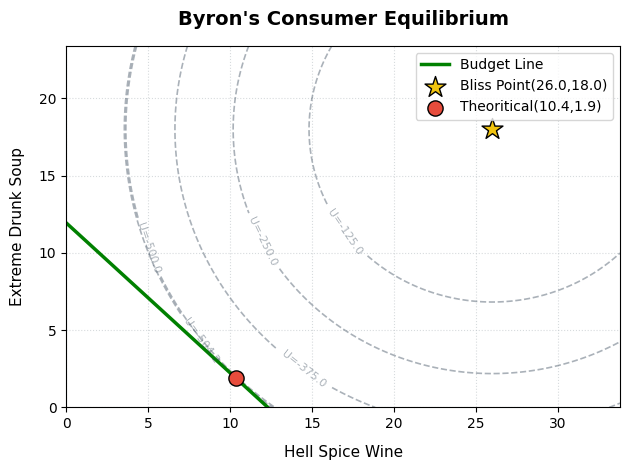

In [ ]:
max_x=max(budget/spicy,sx)*1.3
max_y=max(budget/drunk,sy)*1.3
# 留白
x_grid=np.linspace(0,max_x,300)
y_grid=np.linspace(0,max_y,300)
X,Y=np.meshgrid(x_grid,y_grid)
# meshgrid是為提供的X&Y座標的資料創造座標圖的函式
U=-(X-sx)**2-(Y-sy)**2
max_u=-(b_spicy-sx)**2-(b_drunk-sy)**2
lv=np.unique(np.append(np.linspace(U.min()*0.5,U.max(),5),max_u))
# 繪製等高線的前置作業
# 1.將效用從最小到最大分成10等分 最小乘以0.5防止圖表太擠太貼
# 2.用append將最適組合對標到的無異曲線也加進陣列
# 3.用unique將數值從小到大排列&剔除重複值 contour要求嚴格遞增
contours=plt.contour(X,Y,U,levels=lv,colors="#2c3e50",alpha=0.4,linewidths=1.2)
# 繪製等高線 plt.contour(X,Y,Z,特定高度,...) 效用值視為三維數據
plt.clabel(contours,inline="True",fontsize=8,fmt="U=%.1f")
# 使等高線顯示數值 inline:布林值，數值嵌入線中or數值與線重疊 fmt:格式，數值如何顯示
xx_grid=np.linspace(0,budget/spicy,300)
yy_grid=np.clip((budget-spicy*xx_grid)/drunk,0,None)
plt.plot(xx_grid,yy_grid,label="Budget Line",color="green",linewidth=2.5)
plt.scatter(sx,sy,color="#f1c40f",edgecolor="black",s=250,marker="*",zorder=5,label=f"Bliss Point({sx:.1f},{sy:.1f})")
plt.scatter(b_spicy,b_drunk,color="#e74c3c",edgecolor="black",s=120,marker="o",zorder=6,label=f"Theoritical({b_spicy:.1f},{b_drunk:.1f})")
plt.title("Byron\'s Consumer Equilibrium",fontsize=14,fontweight="bold",pad=15)
plt.xlabel("Hell Spice Wine",fontsize=11,labelpad=10)
plt.ylabel("Extreme Drunk Soup",fontsize=11,labelpad=10)
plt.xlim(0,max_x)
plt.ylim(0,max_y)
plt.grid(True,linestyle=":",alpha=0.6,color="#bdc3c7")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()